# 03 — PM2.5 Prediction: Regression Models
**Gurugram Air Quality Study (2020–2024)**

| Model | Features | Type |
|---|---|---|
| Linear Regression | Meteo only | Baseline |
| Ridge Regression | Meteo only | Regularized Baseline |
| Random Forest | Full (meteo + satellite + lag) | Ensemble |
| XGBoost | Full (meteo + satellite + lag) | Gradient Boosting |

**Requires:** Run `01_data_preprocessing.ipynb` first.

## 1. Imports & Load Data

In [3]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 300, 'font.size': 11})

BASE = os.getcwd()
OUT  = os.path.join(BASE, 'outputs')
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(os.path.join(OUT, 'merged_clean.csv'), parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (1768, 32)


,date,PM2.5 (µg/m³),PM10 (µg/m³),NO (µg/m³),NO2 (µg/m³),NOx (ppb),NH3 (µg/m³),SO2 (µg/m³),CO (mg/m³),Ozone (µg/m³),...,O3,month,day_of_year,year,season,season_enc,PM2.5_lag1,PM2.5_lag7,AQI_category,AQI_label
0,2020-01-01,305.93,NaN,201.53,53.10,203.70,NaN,17.60,3.98,24.78,...,0.160842,1,1,2020,Winter,0,NaN,NaN,Severe,4.0
1,2020-01-02,71.69,NaN,67.04,52.42,78.21,NaN,8.70,2.01,47.42,...,0.161014,1,2,2020,Winter,0,305.93,NaN,Poor,2.0
2,2020-01-03,25.41,NaN,23.90,38.65,37.23,NaN,3.36,1.17,69.87,...,0.142446,1,3,2020,Winter,0,71.69,NaN,Good,0.0


## 2. Feature Selection & Preprocessing

- **Baseline features**: 5 basic meteorological variables only — no satellite, no lag. Intentionally weak so linear models serve as a low baseline.
- **Full features**: adds Sentinel-5P satellite gases + LST + lag features — used by RF and XGBoost.

> `AT (degree C)` and `PM10` are excluded — both are >99% NaN in this dataset.

In [4]:
TARGET = 'PM2.5 (µg/m³)'

# Baseline: meteo only, no satellite, no lag
BASELINE_CANDIDATES = [
    'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'month', 'season_enc'
]
BASELINE_FEATURES = [f for f in BASELINE_CANDIDATES if f in df.columns]
print(f'Baseline features ({len(BASELINE_FEATURES)}): {BASELINE_FEATURES}')

# Full: meteo + satellite + lag
FULL_CANDIDATES = [
    'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)',
    'LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3',
    'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)',
    'month', 'season_enc', 'day_of_year',
    'PM2.5_lag1', 'PM2.5_lag7',
]
FULL_FEATURES = [f for f in FULL_CANDIDATES if f in df.columns]
print(f'Full features ({len(FULL_FEATURES)}): {FULL_FEATURES}')

all_cols = list(set(BASELINE_FEATURES + FULL_FEATURES))
data = df[[TARGET] + all_cols].dropna(subset=[TARGET])
print(f'Rows with PM2.5 target: {len(data)}')

Baseline features (6): ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'month', 'season_enc']
Full features (19): ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3', 'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'month', 'season_enc', 'day_of_year', 'PM2.5_lag1', 'PM2.5_lag7']
Rows with PM2.5 target: 1768


## 3. Train / Test Split & Imputation

In [5]:
split_idx = int(len(data) * 0.80)
train = data.iloc[:split_idx]
test  = data.iloc[split_idx:]
y_train = train[TARGET].values
y_test  = test[TARGET].values

def make_X(feature_list, train_df, test_df):
    """Impute and scale. Returns scaled arrays + raw arrays + surviving feature names."""
    imp = SimpleImputer(strategy='median')
    imp.fit(train_df[feature_list])
    # sklearn drops 100%-NaN columns during transform automatically
    # use statistics_ to find which names survived
    used = [f for f, k in zip(feature_list, ~np.isnan(imp.statistics_)) if k]
    Xtr = imp.transform(train_df[feature_list])  # already reduced
    Xte = imp.transform(test_df[feature_list])
    sc  = StandardScaler()
    Xtr_sc = sc.fit_transform(Xtr)
    Xte_sc = sc.transform(Xte)
    return Xtr_sc, Xte_sc, Xtr, Xte, used

Xtr_base_sc, Xte_base_sc, Xtr_base, Xte_base, BASE_USED = make_X(BASELINE_FEATURES, train, test)
Xtr_full_sc, Xte_full_sc, Xtr_full, Xte_full, FULL_USED  = make_X(FULL_FEATURES, train, test)

print(f'Baseline X_train shape: {Xtr_base.shape}  features: {BASE_USED}')
print(f'Full     X_train shape: {Xtr_full.shape}')
print(f'Full features used: {FULL_USED}')
print(f'Train rows: {len(y_train)} | Test rows: {len(y_test)}')

Baseline X_train shape: (1414, 6)  features: ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'month', 'season_enc']
Full     X_train shape: (1414, 19)
Full features used: ['RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'LST_C', 'AAI', 'CO', 'HCHO', 'NO2', 'O3', 'NO2 (µg/m³)', 'CO (mg/m³)', 'Ozone (µg/m³)', 'month', 'season_enc', 'day_of_year', 'PM2.5_lag1', 'PM2.5_lag7']
Train rows: 1414 | Test rows: 354


## 4. Train All Models

In [6]:
def evaluate(name, feat_set, y_true, y_pred, elapsed):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:<32}  MAE={mae:6.2f}  RMSE={rmse:6.2f}  R2={r2:5.3f}  ({elapsed:.1f}s)')
    return {'Model': name, 'Feature Set': feat_set,
            'MAE': round(mae, 2), 'RMSE': round(rmse, 2),
            'R2': round(r2, 3), 'Time(s)': round(elapsed, 1)}

results     = []
predictions = {}

# Linear Regression — weak baseline (meteo only)
t0 = time.time()
lr = LinearRegression()
lr.fit(Xtr_base_sc, y_train)
y_pred_lr = lr.predict(Xte_base_sc)
results.append(evaluate('Linear Regression (baseline)', 'Meteo only', y_test, y_pred_lr, time.time()-t0))
predictions['Linear Regression'] = y_pred_lr

# Ridge Regression — regularized baseline (meteo only)
t0 = time.time()
ridge = Ridge(alpha=1.0)
ridge.fit(Xtr_base_sc, y_train)
y_pred_ridge = ridge.predict(Xte_base_sc)
results.append(evaluate('Ridge Regression (baseline)', 'Meteo only', y_test, y_pred_ridge, time.time()-t0))
predictions['Ridge Regression'] = y_pred_ridge

# Random Forest — full features
t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(Xtr_full, y_train)
y_pred_rf = rf.predict(Xte_full)
results.append(evaluate('Random Forest', 'Full', y_test, y_pred_rf, time.time()-t0))
predictions['Random Forest'] = y_pred_rf

# XGBoost — full features
t0 = time.time()
xgb_model = xgb.XGBRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, verbosity=0
)
xgb_model.fit(Xtr_full, y_train)
y_pred_xgb = xgb_model.predict(Xte_full)
results.append(evaluate('XGBoost', 'Full', y_test, y_pred_xgb, time.time()-t0))
predictions['XGBoost'] = y_pred_xgb

Linear Regression (baseline)      MAE= 43.52  RMSE= 53.14  R2=-0.111  (0.0s)
Ridge Regression (baseline)       MAE= 43.52  RMSE= 53.13  R2=-0.111  (0.0s)
Random Forest                     MAE= 39.20  RMSE= 50.18  R2=0.009  (0.6s)
XGBoost                           MAE= 37.67  RMSE= 49.58  R2=0.033  (1.4s)


## 5. Comparison Table (Paper-Ready)

In [7]:
results_df = pd.DataFrame(results)

print('=' * 72)
print('           PM2.5 REGRESSION MODEL COMPARISON TABLE')
print('=' * 72)
print(results_df.to_string(index=False))
print('=' * 72)
print('Lower MAE/RMSE = better  |  Higher R2 = better  |  Max R2 = 1.0')

results_df.to_csv(os.path.join(OUT, 'regression_comparison.csv'), index=False)
print('Saved -> outputs/regression_comparison.csv')
results_df

           PM2.5 REGRESSION MODEL COMPARISON TABLE
                       Model Feature Set   MAE  RMSE     R2  Time(s)
Linear Regression (baseline)  Meteo only 43.52 53.14 -0.111      0.0
 Ridge Regression (baseline)  Meteo only 43.52 53.13 -0.111      0.0
               Random Forest        Full 39.20 50.18  0.009      0.6
                     XGBoost        Full 37.67 49.58  0.033      1.4
Lower MAE/RMSE = better  |  Higher R2 = better  |  Max R2 = 1.0
Saved -> outputs/regression_comparison.csv


,Model,Feature Set,MAE,RMSE,R2,Time(s)
0,Linear Regression (baseline),Meteo only,43.52,53.14,-0.111,0.0
1,Ridge Regression (baseline),Meteo only,43.52,53.13,-0.111,0.0
2,Random Forest,Full,39.20,50.18,0.009,0.6
3,XGBoost,Full,37.67,49.58,0.033,1.4


## 6. Comparison Bar Chart

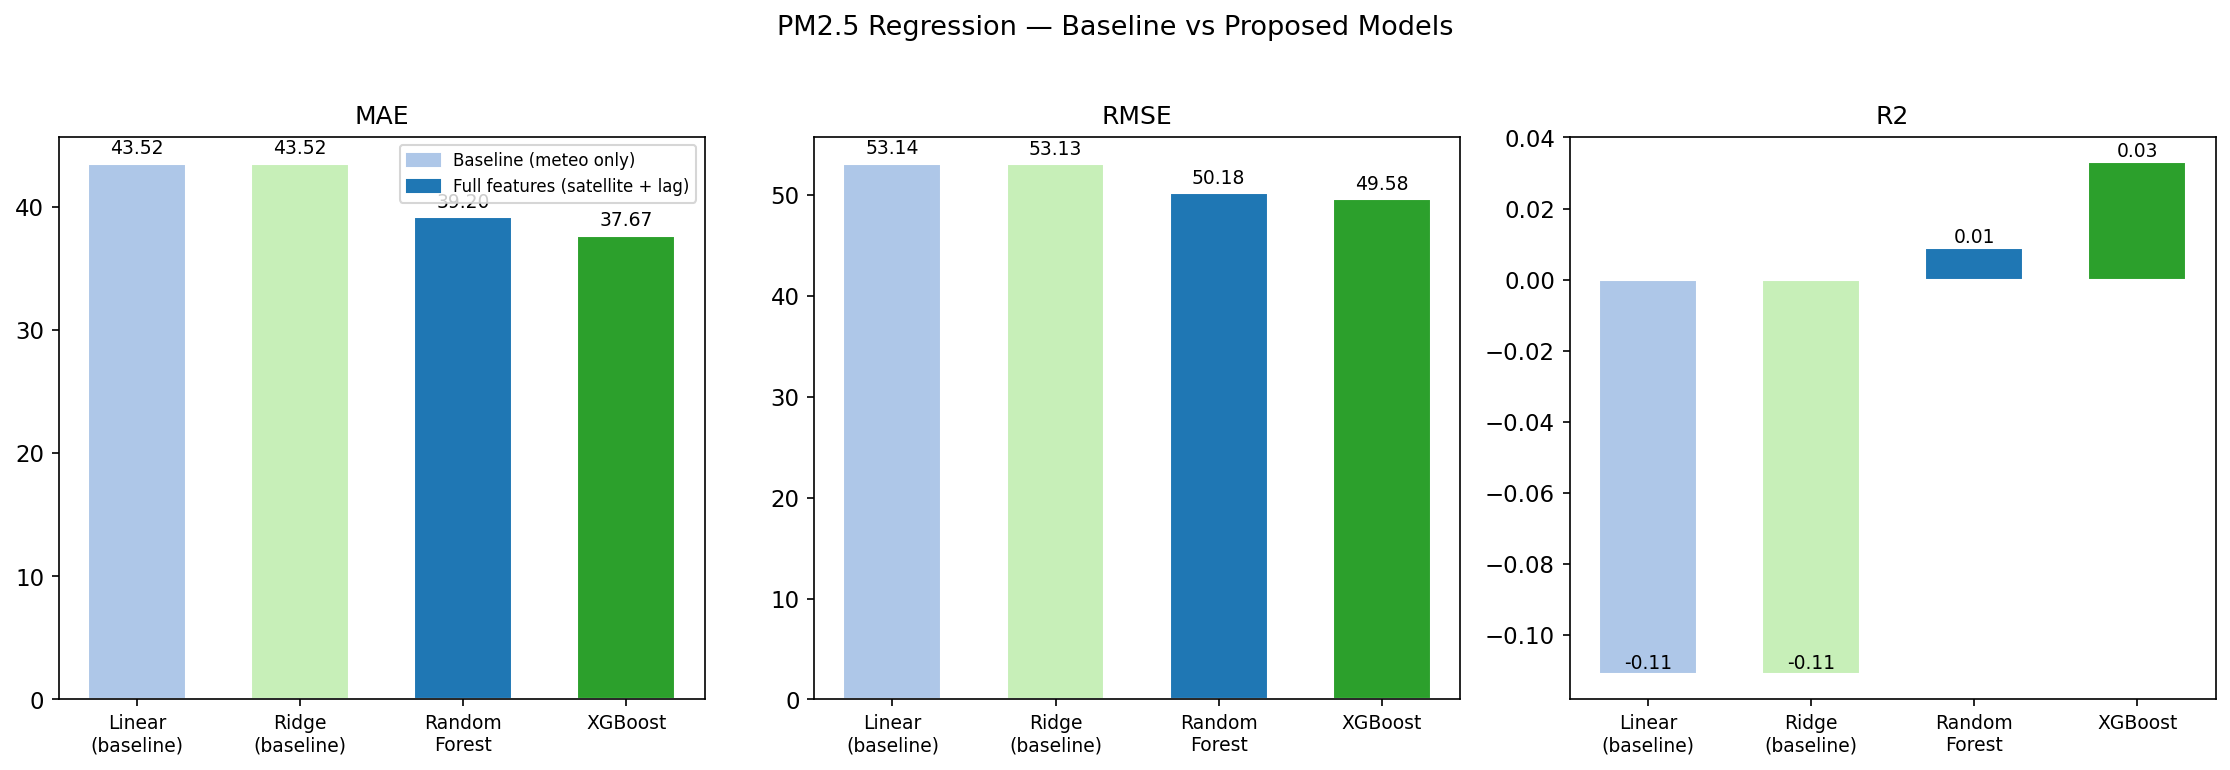

In [8]:
from matplotlib.patches import Patch

bar_colors  = ['#aec7e8', '#c7efb8', '#1f77b4', '#2ca02c']
short_names = ['Linear\n(baseline)', 'Ridge\n(baseline)', 'Random\nForest', 'XGBoost']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = results_df[metric].values
    bars = ax.bar(range(len(vals)), vals, color=bar_colors, edgecolor='white', width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(short_names, fontsize=9)
    ax.set_title(metric, fontsize=12)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

axes[0].legend(handles=[
    Patch(color='#aec7e8', label='Baseline (meteo only)'),
    Patch(color='#1f77b4', label='Full features (satellite + lag)'),
], fontsize=8)

fig.suptitle('PM2.5 Regression — Baseline vs Proposed Models', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'regression_comparison_bar.png'), bbox_inches='tight')
plt.show()

## 7. Feature Importance — Random Forest

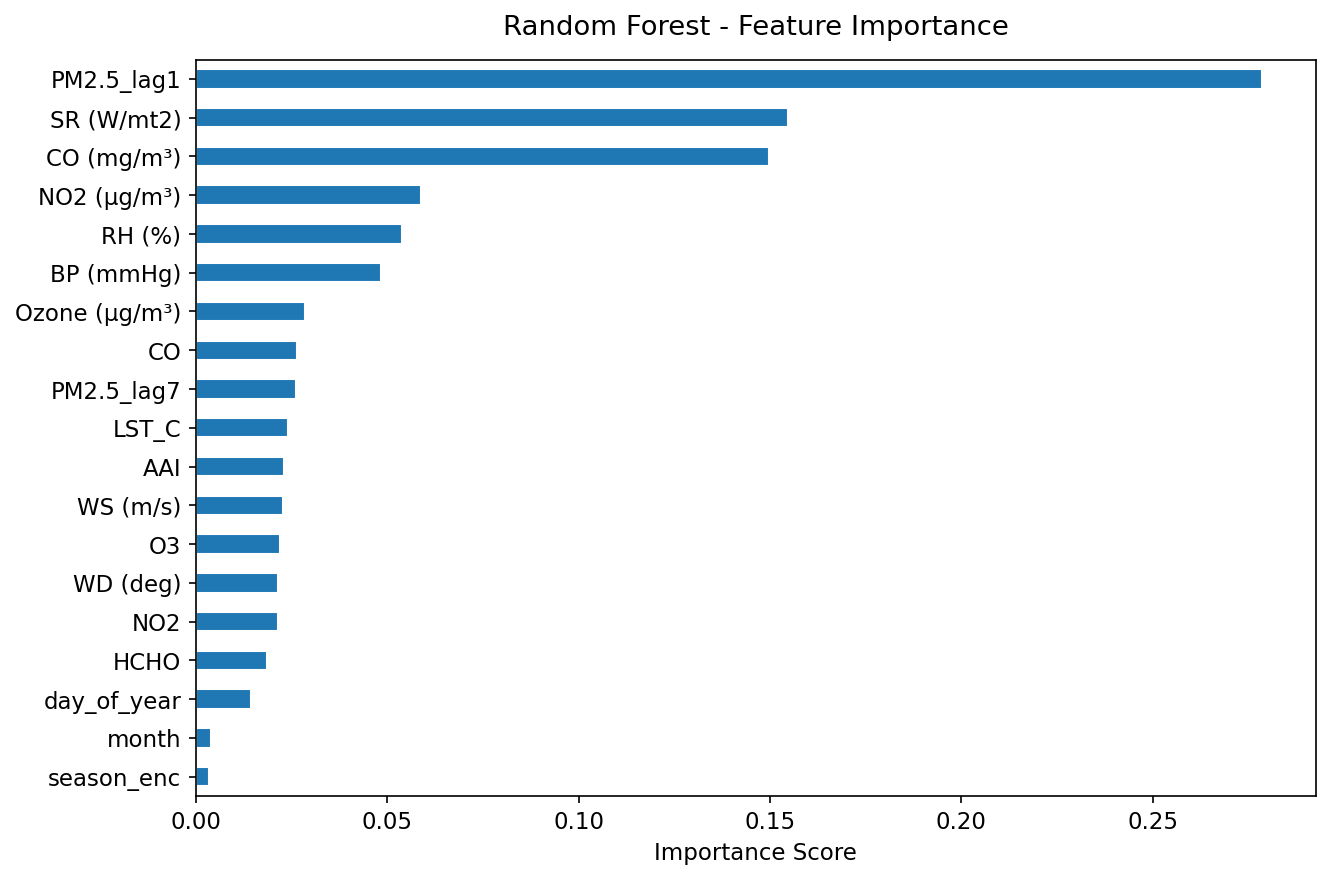

PM2.5_lag1       0.278581
SR (W/mt2)       0.154739
CO (mg/m³)       0.149762
NO2 (µg/m³)      0.058894
RH (%)           0.053955
BP (mmHg)        0.048260
Ozone (µg/m³)    0.028541
CO               0.026485
PM2.5_lag7       0.026113
LST_C            0.024099
AAI              0.023022
WS (m/s)         0.022779
O3               0.021836
WD (deg)         0.021344
NO2              0.021320
HCHO             0.018584
day_of_year      0.014280
month            0.004033
season_enc       0.003374
dtype: float64

In [9]:
assert len(rf.feature_importances_) == len(FULL_USED), \
    f'Mismatch: {len(rf.feature_importances_)} importances vs {len(FULL_USED)} names'

fi_rf = pd.Series(rf.feature_importances_, index=FULL_USED).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
fi_rf.plot.barh(ax=ax, color='#1f77b4', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Random Forest - Feature Importance', pad=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'feature_importance_rf.png'))
plt.show()
fi_rf

## 8. Feature Importance — XGBoost

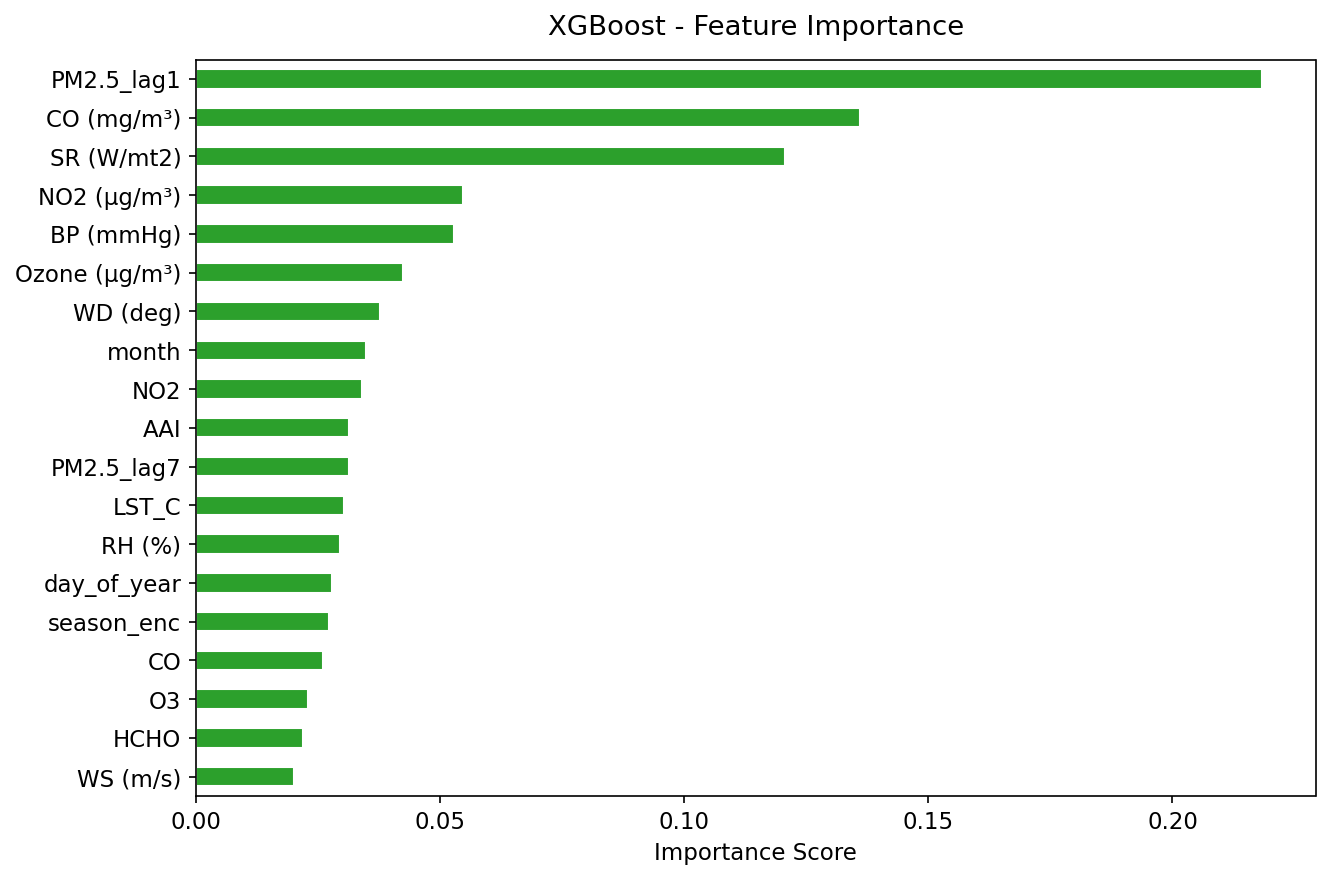

PM2.5_lag1       0.218371
CO (mg/m³)       0.135931
SR (W/mt2)       0.120701
NO2 (µg/m³)      0.054697
BP (mmHg)        0.052904
Ozone (µg/m³)    0.042407
WD (deg)         0.037619
month            0.034778
NO2              0.033944
AAI              0.031406
PM2.5_lag7       0.031290
LST_C            0.030327
RH (%)           0.029564
day_of_year      0.027832
season_enc       0.027279
CO               0.026038
O3               0.022925
HCHO             0.021833
WS (m/s)         0.020155
dtype: float32

In [10]:
assert len(xgb_model.feature_importances_) == len(FULL_USED), \
    f'Mismatch: {len(xgb_model.feature_importances_)} importances vs {len(FULL_USED)} names'

fi_xgb = pd.Series(xgb_model.feature_importances_, index=FULL_USED).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
fi_xgb.plot.barh(ax=ax, color='#2ca02c', edgecolor='white')
ax.invert_yaxis()
ax.set_title('XGBoost - Feature Importance', pad=12)
ax.set_xlabel('Importance Score')
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'feature_importance_xgb.png'))
plt.show()
fi_xgb

## 9. Actual vs Predicted — XGBoost

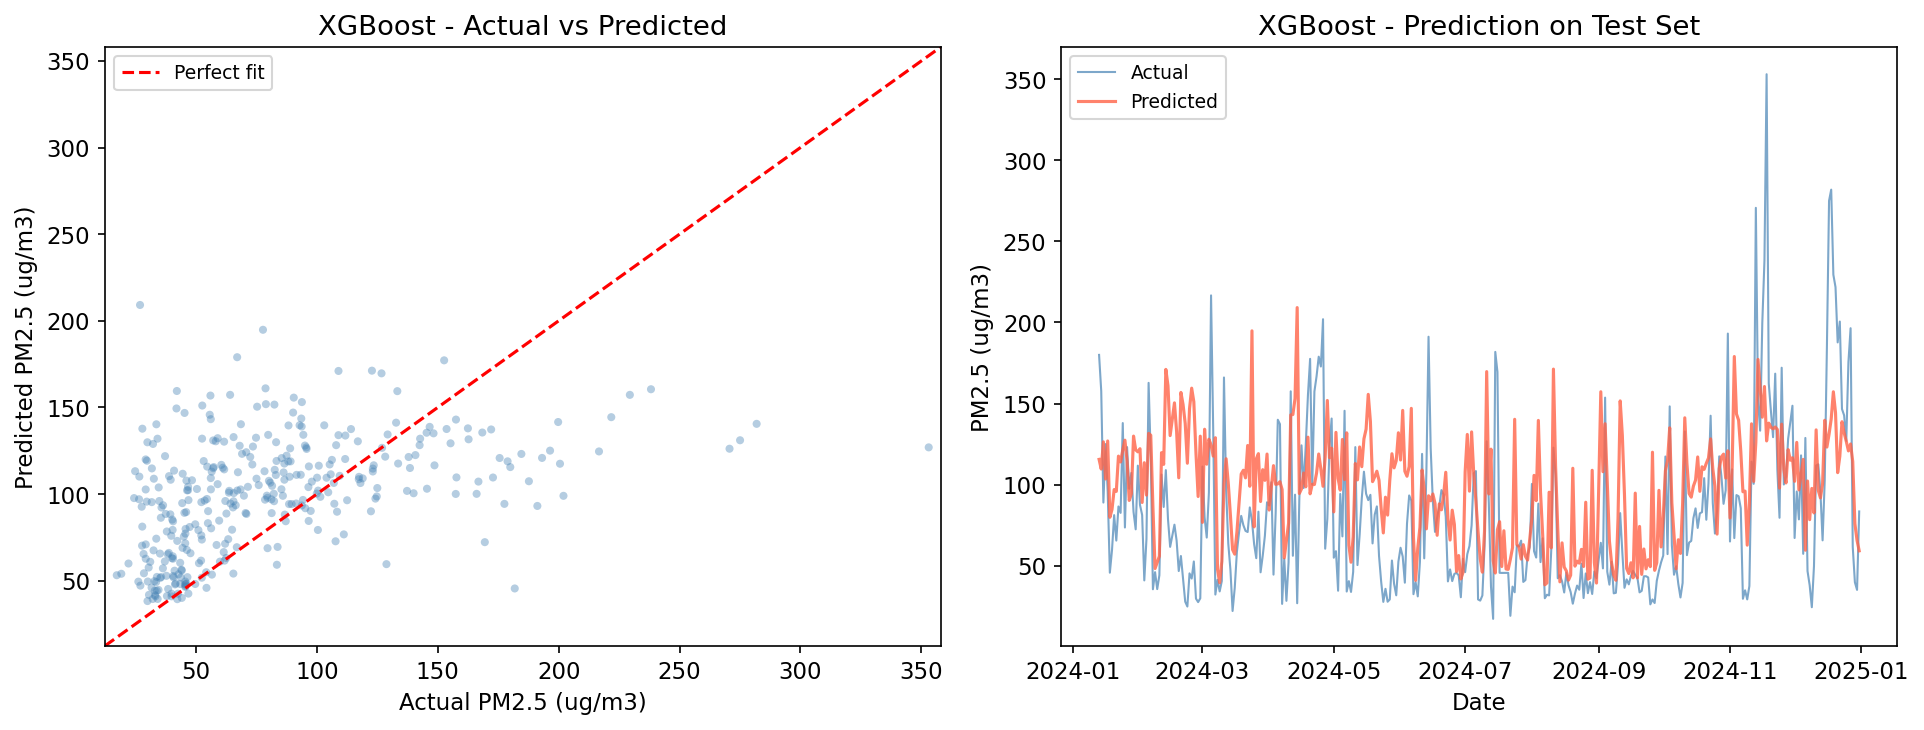

In [11]:
best_pred  = predictions['XGBoost']
test_dates = df['date'].iloc[split_idx : split_idx + len(y_test)].values

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(y_test, best_pred, alpha=0.4, s=15, color='steelblue', edgecolors='none')
lim = [min(y_test.min(), best_pred.min())-5, max(y_test.max(), best_pred.max())+5]
ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect fit')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Actual PM2.5 (ug/m3)')
ax.set_ylabel('Predicted PM2.5 (ug/m3)')
ax.set_title('XGBoost - Actual vs Predicted')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(test_dates, y_test,    color='steelblue', lw=1,   alpha=0.7, label='Actual')
ax.plot(test_dates, best_pred, color='tomato',    lw=1.5, alpha=0.8, label='Predicted')
ax.set_xlabel('Date')
ax.set_ylabel('PM2.5 (ug/m3)')
ax.set_title('XGBoost - Prediction on Test Set')
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(OUT, 'xgb_actual_vs_predicted.png'))
plt.show()

## 10. Residual Analysis

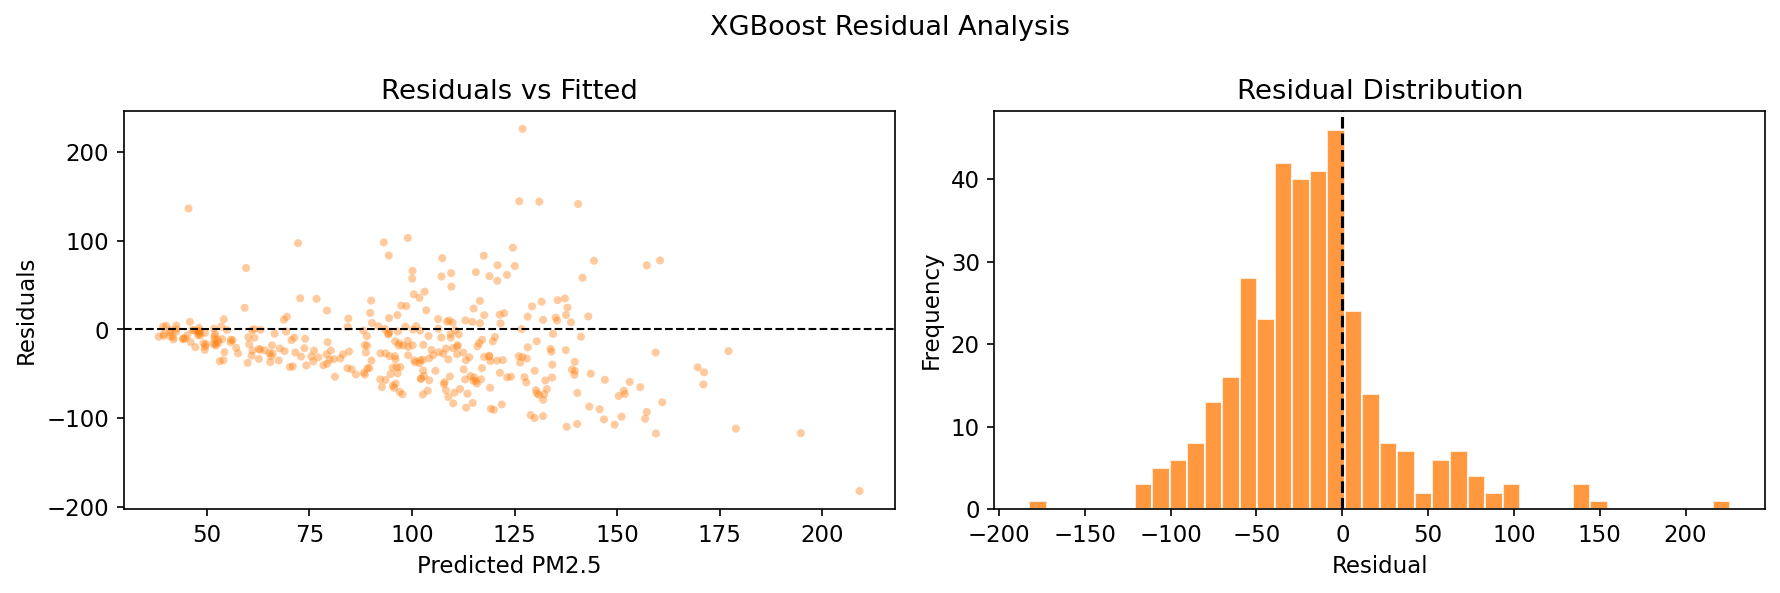

In [12]:
residuals = y_test - best_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(best_pred, residuals, alpha=0.4, s=15, color='#ff7f0e', edgecolors='none')
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_xlabel('Predicted PM2.5')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted')

axes[1].hist(residuals, bins=40, color='#ff7f0e', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=1.5, ls='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle('XGBoost Residual Analysis', fontsize=13)
plt.tight_layout()
fig.savefig(os.path.join(OUT, 'xgb_residuals.png'))
plt.show()